<a href="https://colab.research.google.com/github/shardas06543/Master-s-Thesis/blob/main/Fine_Tune_RoBERTa_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fine-tuning RoBERTa: Broad Based Sentiment Analysis

**The research objectives of this file include the following:**


*   How do different proportions of mixed and synthetic data affect the results of broad-based sentiment analysis, using RoBERTa?
*   Combine the real + synthetic data and lightly preprocess, then save to a CSV file




**This file includes the following sections:**


*   Fine-tuning RoBERTa
*   Implementing RoBERTa (not fine-tuned) for broad-based sentiment analysis only


**How will this information be used?**


*  Compare to popular benchmarks from other models (list them here)


1.   State of the art performance benchmarks include F1 score exceeding 0.95




*Should I use a different model other than RoBERTa, if those outperform this one?*











In [ ]:
!pip install emojis

In [ ]:
# Import all required libraries
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd
import numpy as np
from transformers import TrainingArguments, Trainer
import os
from transformers import AutoTokenizer, AutoModelForSequenceClassification, DataCollatorWithPadding
from scipy.special import softmax
from datasets import Dataset # Import Dataset to create Hugging Face objects. Include the source for this?
import re
from bs4 import BeautifulSoup
import string
from sklearn.model_selection import train_test_split
import duckdb
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, balanced_accuracy_score, accuracy_score, confusion_matrix, recall_score, precision_score, average_precision_score, precision_recall_curve, precision_recall_fscore_support
import seaborn as sns
import emojis

# How do I integrate GPU - is it being used for paraellization? How is it being implemented?

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Preprocessing Synthetic Data**

In [ ]:
def preprocess_text(text):

  # Step 1 - Remove all of the HTML tags (if any)
  soup = BeautifulSoup(text, 'html.parser')
  processed_text = soup.get_text(strip = True) #strip = True removes all leading and trailing whitespace characters

  # Step 2 - convert all the text into lowercase
  lowercase_preprocessed = processed_text.lower()

  # Step 4 - remove all unwanted characters that are not a-z, 0-9,
  # In the report, for all of the functions that we cannot use, explain the rationale in the Thesis report
  cleaned_preprocessed = re.sub(r'(.)\1+', r'\1', text) # This removes duplicate characters / excessive punctuation (for ex: gooood --> good, !!! --> !)
  cleaned_preprocessed = re.sub(r'\s+', ' ', text).strip()

  return cleaned_preprocessed


In [ ]:
train_url = "https://docs.google.com/spreadsheets/d/1y6uN8fmNnY96-NHhtuargCdWndCMyPxidAN33i8ALsk/export?format=csv&gid=1323181601"
#train_url = "/content/drive/MyDrive/MS_Thesis_Shreeya_Sharda/Datasets/train_mixed_70%_real_V2.csv"
train_dataset = pd.read_csv(train_url)
train_dataset = train_dataset[train_dataset['Review'] != '']
# Filter out 'Neutral' sentiment for binary classification
train_dataset = train_dataset[train_dataset['Ground Truth'].str.strip() != 'Neutral']

val_dataset = pd.read_csv("/content/drive/MyDrive/MS_Thesis_Shreeya_Sharda/Datasets/validate_real_data_only.csv")
# Filter out 'Neutral' sentiment for binary classification
val_dataset = val_dataset[val_dataset['Ground Truth'].str.strip() != 'Neutral']

test_dataset = pd.read_csv("/content/drive/MyDrive/MS_Thesis_Shreeya_Sharda/Datasets/test_real.csv")
# Filter out 'Neutral' sentiment for binary classification
test_dataset = test_dataset[test_dataset['Ground Truth'].str.strip() != 'Neutral']

In [ ]:
# Preprocess the reviews
# We added fillna due to a TypeError on the dataset
train_dataset["Review"] = train_dataset["Review"].fillna('').apply(preprocess_text)
val_dataset["Review"] = val_dataset["Review"].fillna('').apply(preprocess_text)
test_dataset["Review"] = test_dataset["Review"].fillna('').apply(preprocess_text)

**Fine-Tuning RoBERTa (multi-classification model)**

In [ ]:
# RobERTa from - from Hugging Face (trained on Twitter)
# MODEL_name = f"cardiffnlp/twitter-roberta-base-sentiment-latest"

# MODEL = AutoModelForSequenceClassification.from_pretrained(MODEL_name)

# tokenizer = AutoTokenizer.from_pretrained(MODEL_name)

In [ ]:
# # Load the id2label and label2id (note - this is a multi-classification problem)

# # NOTE - We are creating a "multi-classification head" -->
# # NOTE - mention this as a small step in the thesis report as part of the process for fine-tuning using a transfer learning approach
# id2label = {0: "Negative", 1:"Neutral", 2:"Positive"}
# label2id = {"Negative": 0, "Neutral": 1, "Positive": 2}


# # Create the new model
# model_multi = AutoModelForSequenceClassification.from_pretrained(MODEL_name, num_labels = 3,
# #                                                                  id2label = id2label,
# #                                                                  label2id = label2id)

# # Training parameters (use a "transfer learning" approach b/c we are freezing all of the model parameters except for the last 4 layers)
# # step 1 - Freeze all of the parameters which are not in the new multi-classification head defined above
# for param in model_multi.base_model.parameters():
# #  param.requires_grad = False #

# # step 2 - unfreeze any layers with the name "pooler" within it - these parameters are going to be used in the fine-tuning process
# for name, param in model_multi.base_model.named_parameters():
# #  if "pooler" in name:
# #    param.requires_grad = True

# # Step 3 - Tokenization function for the Dataset. We are aiming to convert the text data into a read-able format for the RoBERTa archiecture to use
# # NOTE - Within this function, we are NOT padding or returning the tensors as we originally did when we did not use fine-tuning.
# # NOTE - We are returning the input_ids and the attention_mask (COME BACK HERE)
# def tokenize_function(examples):

# #    tokenized_inputs = tokenizer(examples["Review"], truncation=True, max_length=512)

# #    # This line makes sense because when we do (**encoded_text) without fine-tuning, we are getting input_ids and attention mask
# #    return {
# #        'input_ids': tokenized_inputs['input_ids'],
# #        'attention_mask': tokenized_inputs['attention_mask']
# #    }

**Binary classification model**

We implement a different model for this step from Hugging Face:


In [ ]:
from transformers import RobertaForSequenceClassification, RobertaTokenizer

model_name = "AnkitAI/reviews-roberta-base-sentiment-analysis"
model = RobertaForSequenceClassification.from_pretrained(model_name)
tokenizer = RobertaTokenizer.from_pretrained(model_name)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [ ]:
# Load the id2label and label2id (note - this is a binary classification problem)

# NOTE - We are creating a "binary-classification head" -->
# NOTE - mention this as a small step in the thesis report as part of the process for fine-tuning using a transfer learning approach
id2label = {0: "Negative", 1:"Positive"}
label2id = {"Negative": 0, "Positive": 1}


# Create the new model
model_multi = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels = 2,
                                                                 id2label = id2label,
                                                                 label2id = label2id,
                                                                 ignore_mismatched_sizes=True)

# Training parameters (use a "transfer learning" approach b/c we are freezing all of the model parameters except for the last 4 layers)
# step 1 - Freeze all of the parameters which are not in the new multi-classification head defined above
for param in model_multi.base_model.parameters():
  param.requires_grad = False #

# step 2 - unfreeze any layers with the name "pooler" within it - these parameters are going to be used in the fine-tuning process
for name, param in model_multi.base_model.named_parameters():
  if "pooler" in name:
    param.requires_grad = True

# Step 3 - Tokenization function for the Dataset. We are aiming to convert the text data into a read-able format for the RoBERTa archiecture to use
   # SOURCE: We also leveraged the "code-fixing" feature offered by Google Collab Notebook for the fine-tuning step - (mentioning this for transparency.)

# NOTE - Within this function, we are NOT padding or returning the tensors as we originally did when we did not use fine-tuning.
# NOTE - We are returning the input_ids and the attention_mask (COME BACK HERE)
def tokenize_function(examples):

    tokenized_inputs = tokenizer(examples["Review"], truncation=True, max_length=512)

    # This line makes sense because when we do (**encoded_text) without fine-tuning, we are getting input_ids and attention mask
    return {
        'input_ids': tokenized_inputs['input_ids'],
        'attention_mask': tokenized_inputs['attention_mask']
    }

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

**Convert the datasets to Hugging Face objects so they can be passed to Trainer and Training Args**


In [ ]:
# Step 4 - Use one-hot encoding to convert the train and validation labels to numbers as shown in the dictionary
train_labels = train_dataset["Ground Truth"].str.strip().apply(lambda x: label2id[x]).tolist() # Convert string labels to integer IDs
val_labels = val_dataset["Ground Truth"].str.strip().apply(lambda x: label2id[x]).tolist() # Convert string labels to integer IDs
test_labels = test_dataset["Ground Truth"].str.strip().apply(lambda x: label2id[x]).tolist() # Convert string labels to integer IDs

In [ ]:
# Step 5 - Convert the datasets to hugging face objects because data_collator only operates on this
train_dataset = Dataset.from_dict({'Review': train_dataset["Review"], 'labels': train_labels})
val_dataset = Dataset.from_dict({'Review': val_dataset["Review"], 'labels': val_labels})
test_dataset = Dataset.from_dict({'Review': test_dataset["Review"], 'labels': test_labels})

**Tokenize the train and validation datasets**

In [ ]:
# Step 6 - Apply the tokenization function to the datasets
# batched = True --> this parameter indicates that the tokenize function does not run each value one at a time and instead runs in batches for faster runtime
tokenized_train_dataset = train_dataset.map(tokenize_function, batched=True)
tokenized_val_dataset = val_dataset.map(tokenize_function, batched=True)
tokenized_test_dataset = test_dataset.map(tokenize_function, batched=True)

#print(type(tokenized_train_dataset)) # This is of type: <class 'datasets.arrow_dataset.Dataset'>


Map:   0%|          | 0/795 [00:00<?, ? examples/s]

Map:   0%|          | 0/214 [00:00<?, ? examples/s]

Map:   0%|          | 0/492 [00:00<?, ? examples/s]

In [ ]:
os.environ["WANDB_DISABLED"] = "true"

**Define metrics to be computed by the Trainer function**

In [ ]:
def evaluate_metrics(eval_pred):
  logits, labels = eval_pred
  predictions = np.argmax(logits, axis=-1) # NOTE - axis = -1

  macro_f1 = f1_score(labels, predictions, average='macro')
  bal_acc = balanced_accuracy_score(labels, predictions)
  confusion_mat = confusion_matrix(labels, predictions).tolist() # Convert ndarray to list for JSON serialization ()

  # Removed precision_recall_curve and average_precision_score as they are not directly supported for multiclass
  macro_recall = recall_score(labels, predictions, average = 'macro')
  macro_precision = precision_score(labels, predictions, average = 'macro')
  precision, recall, f1, support = precision_recall_fscore_support(
    labels, predictions, average=None
)

  per_class_metrics = {}
  num_classes = 2 # Changed to 2 for binary classification
  class_names = list(id2label.values()) # This will correctly set class_names to ['Negative', 'Positive']


  for i, cls_name in enumerate(class_names):
        per_class_metrics[cls_name] = {
            "precision": float(precision[i]),
            "recall": float(recall[i]),
            "f1": float(f1[i]),
            "support": int(support[i])
        }


  return {
          "per_class_metrics": per_class_metrics,
          "macro_f1": macro_f1,
          "balanced_accuracy": bal_acc,
          "confusion_matrix": confusion_mat,
          "macro_precision":macro_precision,
          "macro_recall":macro_recall
          }

**Hyperparameter Tuning**

In [ ]:
# Step 8 - use a data collator to ensure uniform length for batches
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# Step 9 - set the hyperparameters
learning_rate = 2e-5
batch_size = 8 # NOTE - I chose this number based on the given youtube video as a starting point
num_epochs = 10 # NOTE - I chose this number based on the given youtube video as a starting point
output_dir = "/content/drive/MyDrive/MS_Thesis_Shreeya_Sharda/roberta_code/exp_binary_70_Real"

training_param = TrainingArguments(
    output_dir = output_dir,
    learning_rate = learning_rate,
    per_device_train_batch_size = batch_size,
    per_device_eval_batch_size = batch_size,
    num_train_epochs = num_epochs,
    logging_strategy = "epoch",
    eval_strategy = "epoch",
    save_strategy = "epoch", # This means the model saves at every epoch
    load_best_model_at_end=True, # The model loads the version that was at the best epoch (so the lowest validation and training loss)
    greater_is_better=False,
    metric_for_best_model="eval_loss" #Take the model with the lowest validation loss



)

trainer = Trainer(
    model = model_multi,
    args = training_param,
    train_dataset = tokenized_train_dataset,
    eval_dataset = tokenized_val_dataset, #This is the dev dataset
    data_collator = data_collator,
    compute_metrics = evaluate_metrics
)

In [ ]:
trainer.train()

# In report - define what loss function is being used to calculate training and validation loss

Epoch,Training Loss,Validation Loss,Per Class Metrics,Macro F1,Balanced Accuracy,Confusion Matrix,Macro Precision,Macro Recall
1,0.537170,0.077850,"{'Negative': {'precision': 1.0, 'recall': 0.9494949494949495, 'f1': 0.9740932642487047, 'support': 99}, 'Positive': {'precision': 0.9583333333333334, 'recall': 1.0, 'f1': 0.9787234042553191, 'support': 115}}",0.976408,0.974747,"[[94, 5], [0, 115]]",0.979167,0.974747
2,0.284436,0.312381,"{'Negative': {'precision': 0.7424242424242424, 'recall': 0.98989898989899, 'f1': 0.8484848484848485, 'support': 99}, 'Positive': {'precision': 0.9878048780487805, 'recall': 0.7043478260869566, 'f1': 0.8223350253807107, 'support': 115}}",0.835410,0.847123,"[[98, 1], [34, 81]]",0.865115,0.847123
3,0.100498,1.053539,"{'Negative': {'precision': 0.47368421052631576, 'recall': 1.0, 'f1': 0.6428571428571429, 'support': 99}, 'Positive': {'precision': 1.0, 'recall': 0.043478260869565216, 'f1': 0.08333333333333333, 'support': 115}}",0.363095,0.521739,"[[99, 0], [110, 5]]",0.736842,0.521739
4,0.029929,1.832420,"{'Negative': {'precision': 0.46261682242990654, 'recall': 1.0, 'f1': 0.6325878594249201, 'support': 99}, 'Positive': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'support': 115}}",0.316294,0.500000,"[[99, 0], [115, 0]]",0.231308,0.500000
5,0.013123,2.192941,"{'Negative': {'precision': 0.46261682242990654, 'recall': 1.0, 'f1': 0.6325878594249201, 'support': 99}, 'Positive': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'support': 115}}",0.316294,0.500000,"[[99, 0], [115, 0]]",0.231308,0.500000
6,0.008487,2.421767,"{'Negative': {'precision': 0.46261682242990654, 'recall': 1.0, 'f1': 0.6325878594249201, 'support': 99}, 'Positive': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'support': 115}}",0.316294,0.500000,"[[99, 0], [115, 0]]",0.231308,0.500000
7,0.006661,2.552347,"{'Negative': {'precision': 0.46261682242990654, 'recall': 1.0, 'f1': 0.6325878594249201, 'support': 99}, 'Positive': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'support': 115}}",0.316294,0.500000,"[[99, 0], [115, 0]]",0.231308,0.500000
8,0.005345,2.646813,"{'Negative': {'precision': 0.46261682242990654, 'recall': 1.0, 'f1': 0.6325878594249201, 'support': 99}, 'Positive': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'support': 115}}",0.316294,0.500000,"[[99, 0], [115, 0]]",0.231308,0.500000
9,0.004737,2.701664,"{'Negative': {'precision': 0.46261682242990654, 'recall': 1.0, 'f1': 0.6325878594249201, 'support': 99}, 'Positive': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'support': 115}}",0.316294,0.500000,"[[99, 0], [115, 0]]",0.231308,0.500000
10,0.004816,2.723130,"{'Negative': {'precision': 0.46261682242990654, 'recall': 1.0, 'f1': 0.6325878594249201, 'support': 99}, 'Positive': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'support': 115}}",0.316294,0.500000,"[[99, 0], [115, 0]]",0.231308,0.500000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=1000, training_loss=0.09952028053998947, metrics={'train_runtime': 226.3585, 'train_samples_per_second': 35.121, 'train_steps_per_second': 4.418, 'total_flos': 1104766321464480.0, 'train_loss': 0.09952028053998947, 'epoch': 10.0})

In [ ]:
# This gets the model at the epoch with the lowest training and validation loss
trainer.state.best_model_checkpoint

'/content/drive/MyDrive/MS_Thesis_Shreeya_Sharda/roberta_code/exp_binary_70_Real/checkpoint-100'

**Get the trainer and validation loss (to demonstrate the fine-tuning process in the model)**

In [ ]:
# source:
log_history = trainer.state.log_history
log_history
epochs = [x for x in range(1, 11)]

# NOTE - train_loss is equivalent to "loss" and validation loss is "eval_loss"
train_losses = [log['loss'] for log in log_history if 'loss' in log]
val_losses = [log['eval_loss'] for log in log_history if 'eval_loss' in log]
# The test loss is not being recorded per epoch


In [ ]:
# In the report - chart the values of the fine-tuning process.
log_df = pd.DataFrame(trainer.state.log_history)
log_df.to_csv("/content/drive/MyDrive/MS_Thesis_Shreeya_Sharda/Fine_Tune_Performance_0%_real_binary2.csv", index=False)


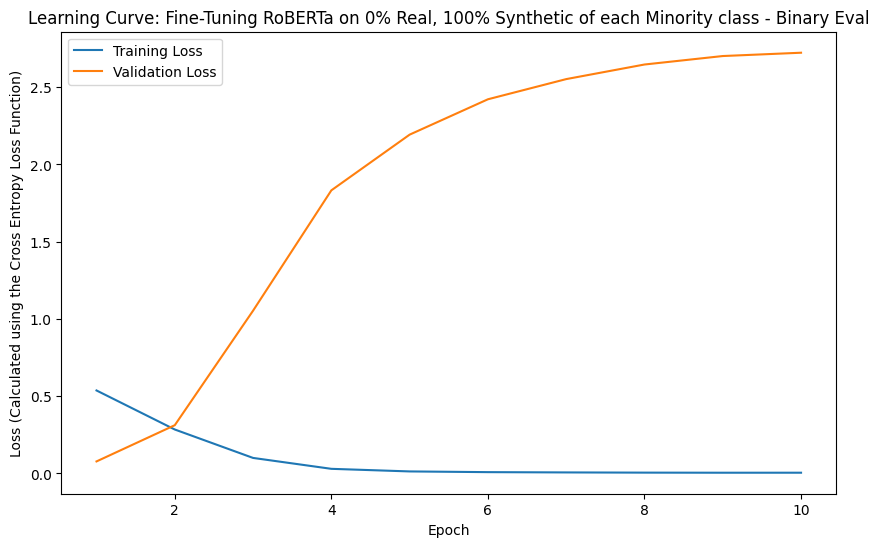

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(epochs, train_losses, label='Training Loss')
plt.plot(epochs, val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (Calculated using the Cross Entropy Loss Function)')
plt.title('Learning Curve: Fine-Tuning RoBERTa on 0% Real, 100% Synthetic of each Minority class - Binary Eval')
plt.legend()
plt.savefig("/content/drive/MyDrive/MS_Thesis_Shreeya_Sharda/Figures/Fine_Tune_Learning_Curve_00%_real_binary2.png")

**Evaluate the fine-tune model on test dataset**

In [ ]:
checkpoint_path = trainer.state.best_model_checkpoint
print(checkpoint_path)
trainer.evaluate(tokenized_test_dataset, metric_key_prefix="test") #metric_key_prefix = "test" will append test to the column names printed
# trainer.evaluate does not produce results for each epoch. It provides a snapshot only

/content/drive/MyDrive/MS_Thesis_Shreeya_Sharda/roberta_code/exp_binary_70_Real/checkpoint-100


{'test_loss': 0.11348272860050201,
 'test_per_class_metrics': {'Negative': {'precision': 0.9745762711864406,
   'recall': 0.9504132231404959,
   'f1': 0.9623430962343096,
   'support': 242},
  'Positive': {'precision': 0.953125,
   'recall': 0.976,
   'f1': 0.9644268774703557,
   'support': 250}},
 'test_macro_f1': 0.9633849868523326,
 'test_balanced_accuracy': 0.963206611570248,
 'test_confusion_matrix': [[230, 12], [6, 244]],
 'test_macro_precision': 0.9638506355932204,
 'test_macro_recall': 0.963206611570248,
 'test_runtime': 8.8568,
 'test_samples_per_second': 55.551,
 'test_steps_per_second': 7.0,
 'epoch': 10.0}

**Get confusion matrix**

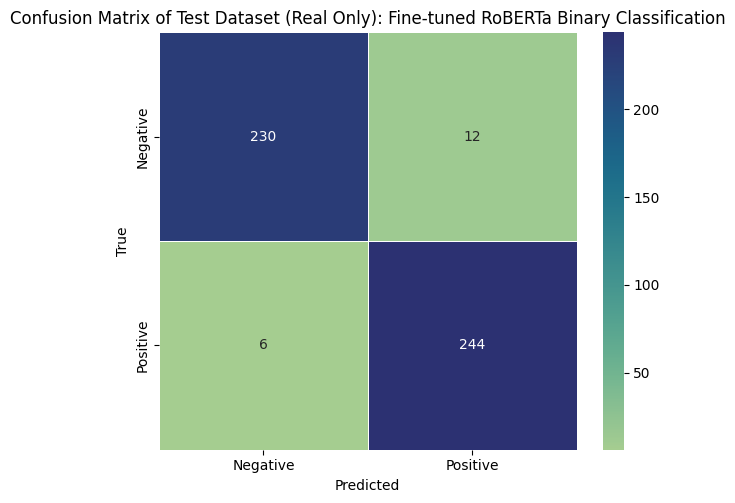

In [ ]:
cm = np.array([[230, 12], [6, 244]]) # Updated to reflect the binary confusion matrix from the evaluation results

# Define classes using the global id2label dictionary
classes = list(id2label.values())

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="crest",
    linewidths=0.5,
    square=True,
    xticklabels=classes,
    yticklabels=classes
)

plt.title("Confusion Matrix of Test Dataset (Real Only): Fine-tuned RoBERTa Binary Classification")
plt.xlabel("Predicted")
plt.ylabel("True")

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/MS_Thesis_Shreeya_Sharda/Figures/Confusion Matrix_100%_LLM_binary.png", bbox_inches="tight", dpi=300)
plt.show()